# 08 - Auditoria: otras tecnicas de explicabilidad

**Objetivo:** complementar las tres auditorias obligatorias (subrogado en `05`, contrafactuales
en `06`, SHAP en `07`) con las **"otras tecnicas que los estudiantes consideren oportunas"** que
invita explicitamente el enunciado (`taller_XAI.pdf`, seccion 1). Se eligen tecnicas que (a) estan
en el propio material del profesor (`XAI.pdf`) pero no son ninguna de las tres obligatorias, y
(b) aportan **reflexion critica** (el otro 50% de la nota), no solo mas graficas.

Este notebook es **autocontenido e independiente de `06` y `07`**: carga los mismos artefactos que
`05` (los dos modelos de caja negra ya entrenados y `test.parquet`) y no necesita nada de la
auditoria de contrafactuales ni de SHAP para ejecutarse.

**Entregable(s) que produce este notebook:**
- `results/tables/otras_08_permutacion_importancia_coste1.csv` / `_coste10.csv`
- `results/tables/otras_08_lime_local.csv`
- `results/tables/otras_08_subgrupos_edad.csv`
- `results/figures/otras_08_*.png` (permutacion, PDP/ICE, PDP 2D de interaccion, LIME, subgrupos)

> Prefijo `otras_08_` (no `08_`) a proposito: los ficheros `08_*.png` / `08_*.csv` de `results/`
> ya los genera la **seccion 8 del EDA (`01_EDA.ipynb`)**; usar `otras_08_` evita pisarlos.

## Conectores

**Que recibe de los notebooks anteriores:**
- `results/models/modelo_coste1.joblib` (de `03_modelo_coste1.ipynb`)
- `results/models/modelo_coste10.joblib` (de `04_modelo_coste10.ipynb`)
- `data/processed/train.parquet` y `data/processed/test.parquet` (de `02_preprocesado.ipynb`;
  `test.parquet` incluye el target real, para el analisis de subgrupos y para seleccionar casos
  denegados de forma autocontenida)
- `results/models/preprocessing_pipeline.joblib` (de `02_preprocesado.ipynb`), para traducir
  umbrales/valores de la escala estandarizada a la escala original (euros/anios/ratios) al narrar
  los PDP y las explicaciones LIME, igual que hace `05`
- `results/tables/sub_05_importancia_variables.csv` (de `05_auditoria_subrogado.ipynb`), para el
  contraste de importancia a 3 bandas de la seccion 2

**Que entrega a los notebooks siguientes:**
- Las tablas y figuras `otras_08_*`, consumidas por `99_ENTREGA.ipynb`
  (**seccion 11, "Otras tecnicas de explicabilidad consideradas"**).

## Decisiones que afectan a este notebook

- **D-0.3** (familia de modelo): **CERRADA** a favor de **XGBoost** (caja negra comun a ambos
  escenarios). Las tecnicas de este notebook son **agnosticas al modelo** (permutacion, PDP/ICE,
  LIME): funcionan sobre `predict_proba` sin asumir que el modelo es un arbol, por lo que sirven
  de contraste independiente frente a SHAP (que aqui usaria el `TreeExplainer`, especifico de
  arboles).
- **Escenario 2 asimetrico** (D-3.2, **CERRADA**): el "10" del escenario 2 es una errata
  confirmada por el profesor; el coste es asimetrico `C_FN = 10*C_FP`, con umbral de decision
  **0.0906** (frente a **0.4934** del escenario 1). Cada tecnica se reporta para **ambos**
  modelos de coste, porque el hallazgo de `05` es que el mismo XGBoost tiene "dos personalidades
  de riesgo" segun el umbral: este notebook busca corroborarlo con metodos distintos.
- **D-8.1 (CERRADA): tecnicas incluidas.** Conjunto final, las cuatro presentes en `XAI.pdf` y
  ninguna de las 3 obligatorias: (1) **importancia por permutacion** (p.166), (2) **PDP + ICE**
  y un **PDP 2D de interaccion** (pp.147-165), (3) **LIME local** como contraste critico frente a
  SHAP (pp.181-199), y (4) **subgrupos por tramo de edad** como mini-auditoria de sesgo
  (motivado por que el material clasifica el credito como sistema de **alto riesgo** bajo el
  reglamento europeo de IA, p.232, y por el hallazgo de `05` de que la caja negra "penaliza la
  juventud"). Se descartaron ALE y Anchors por acotar el alcance a lo que aporta lectura critica
  nueva sin alargar el notebook innecesariamente (traza completa en `docs/DECISIONES.md`, esta misma entrada).
- **D-8.2 (CERRADA): muestreo para tecnicas lentas.** PDP/ICE corren sobre una muestra aleatoria
  simple de **2000** de las 21000 filas de test (semilla 42); la importancia por permutacion sobre
  una muestra de 3000 filas (10 repeticiones); LIME corre sobre casos individuales concretos (no
  necesita submuestra, es local). Declarado aqui explicitamente: nada de recortes silenciosos.
- **Nota tecnica importante (verificada empiricamente):** el wrapper `ModeloBoosted`
  (`src/modeling.py`) NO es compatible con `sklearn.inspection.PartialDependenceDisplay`/
  `partial_dependence` (no hereda de `BaseEstimator`, falta `__sklearn_tags__`). Las funciones de
  PDP de este notebook reciben el **estimador nativo** (`bundle["modelo"].estimador_`, el
  `XGBClassifier` real), cuyas predicciones son **identicas** al wrapper (max|dif|=0.0,
  verificado) cuando `X` se pasa en el orden canonico de columnas. La importancia por permutacion
  SI acepta el wrapper directamente (no exige tags de sklearn con un `scoring` callable).

## 1. Carga de modelos y datos (autocontenida)

Cargamos los dos bundles de `03`/`04` y `test.parquet`, sin importar `src.modeling` (que
arrastraria TensorFlow/Keras por los MLP), exactamente igual que en `05`. Verificamos la
integridad de los estimadores heredados (que el modelo que se carga ES el que se entreno) antes
de auditarlos, y dejamos a mano el pipeline de preprocesado para traducir a escala original.

In [1]:
# === Configuracion - notebook 08 (auditoria: otras tecnicas de explicabilidad) ===
# NOTA: igual que 05, este notebook NO importa src.modeling directamente (evita arrastrar
# TensorFlow/Keras); cargamos los bundles ya entrenados con joblib y usamos src.xai_utils
# (funciones puras) + src.cost_utils.
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# cwd = raiz del repo -> rutas SIN "../" (mismo contrato que 02-05).
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
import src.cost_utils as cu
import src.xai_utils as xu

RANDOM_STATE = 42
TARGET = cu.TARGET
np.random.seed(RANDOM_STATE)

# --- Paleta heredada de 01-05 (coherencia visual del proyecto) ---
COLOR_TARGET = {0: "#2a78d6", 1: "#e34948"}
COLOR_INK_PRIMARY = "#0b0b0b"
COLOR_INK_SECONDARY = "#52514e"
COLOR_MUTED = "#898781"
COLOR_GRID = "#e1e0d9"
COLOR_BASELINE = "#c3c2b7"
COLOR_GANADOR = "#1c5cab"
COLOR_ESC1 = "#8aa9cf"                # esc1 (simetrico)  - azul suave
COLOR_ESC2 = "#b5462f"                # esc2 (asimetrico) - teja

plt.rcParams.update({
    "figure.figsize": (8, 5), "figure.dpi": 130, "savefig.dpi": 130,
    "axes.edgecolor": COLOR_BASELINE, "axes.labelcolor": COLOR_INK_PRIMARY,
    "text.color": COLOR_INK_PRIMARY, "xtick.color": COLOR_MUTED,
    "ytick.color": COLOR_MUTED, "grid.color": COLOR_GRID, "axes.grid": True,
    "grid.linewidth": 0.6, "axes.spines.top": False, "axes.spines.right": False,
})
sns.set_style("white")


def guardar_figura(fig, nombre):
    """Guarda en results/figures/{nombre}.png (prefijo otras_08_)."""
    os.makedirs("results/figures", exist_ok=True)
    fig.tight_layout()
    fig.savefig(f"results/figures/{nombre}.png", dpi=130, bbox_inches="tight")
    plt.show()


def guardar_tabla(df, nombre, index=False):
    """Guarda en results/tables/{nombre}.csv (prefijo otras_08_)."""
    os.makedirs("results/tables", exist_ok=True)
    ruta = f"results/tables/{nombre}.csv"
    df.to_csv(ruta, index=index)
    return ruta


# --- Carga autocontenida: los dos bundles + test/train + pipeline (mismo patron que 05) ---
bundle1 = joblib.load("results/models/modelo_coste1.joblib")
bundle10 = joblib.load("results/models/modelo_coste10.joblib")
pipeline = joblib.load("results/models/preprocessing_pipeline.joblib")
train = pd.read_parquet("data/processed/train.parquet")
test = pd.read_parquet("data/processed/test.parquet")

FEATURES = list(bundle1["features"])          # 12 columnas, orden canonico del contrato
X_train = train[FEATURES].copy()
X_test = test[FEATURES].copy()
y_real = test[TARGET].to_numpy(dtype=int)

modelo_c1 = bundle1["modelo"]                 # wrapper ModeloBoosted (mismo estimador en 03/04)
modelo_c10 = bundle10["modelo"]
umbral_c1 = float(bundle1["umbral"])          # ~0.4934 (simetrico)
umbral_c10 = float(bundle10["umbral"])        # ~0.0906 (asimetrico)

# --- Verificacion de integridad heredada (mismo patron que 05, hallazgo 1.1: D-0.2, un solo
#     scoring y dos umbrales) ---
proba_c1 = np.asarray(modelo_c1.predict_proba(X_test))[:, 1].astype("float64")
proba_c10 = np.asarray(modelo_c10.predict_proba(X_test))[:, 1].astype("float64")
dif_scoring = float(np.max(np.abs(proba_c1 - proba_c10)))
assert dif_scoring < 1e-9, f"D-0.2 ROTA: los scorings de 03 y 04 difieren (max|dif|={dif_scoring})"

pred_c1 = cu.aplicar_umbral(proba_c1, umbral_c1)
pred_c10 = cu.aplicar_umbral(proba_c10, umbral_c10)
deny_c1 = float(pred_c1.mean())
deny_c10 = float(pred_c10.mean())

coste_test_c1 = cu.coste_esperado(y_real, pred_c1, bundle1["C_FP"], bundle1["C_FN"])
coste_test_c10 = cu.coste_esperado(y_real, pred_c10, bundle10["C_FP"], bundle10["C_FN"])

print(f"[D-0.2] mismo scoring en ambos escenarios: max|dif| = {dif_scoring:.2e}  -> confirmado")
print()
print(f"test: {X_test.shape}  features: {len(FEATURES)}")
print(f"umbral coste1  = {umbral_c1:.6f}  -> deniega {deny_c1*100:.2f}% "
      f"({int(pred_c1.sum())}/{len(pred_c1)})  coste_test={coste_test_c1:.4f}")
print(f"umbral coste10 = {umbral_c10:.6f}  -> deniega {deny_c10*100:.2f}% "
      f"({int(pred_c10.sum())}/{len(pred_c10)})  coste_test={coste_test_c10:.4f}")

# --- Traduccion de la columna age a escala real (para PDP y subgrupos; 'age' viene
#     estandarizada en test.parquet, verificado: mean~0, std~1) ---
edad_original = xu.columna_a_original(pipeline, "age", X_test["age"].values)
print(f"\nedad real en test: min={edad_original.min():.0f}, max={edad_original.max():.0f}")

# --- Muestra aleatoria simple (D-8.2) para tecnicas lentas (PDP/ICE) ---
N_MUESTRA_PDP = 2000
idx_muestra = X_test.sample(N_MUESTRA_PDP, random_state=RANDOM_STATE).index
X_muestra = X_test.loc[idx_muestra]
print(f"\n[D-8.2] muestra aleatoria simple para PDP/ICE: {N_MUESTRA_PDP} de {len(X_test)} filas "
      f"({N_MUESTRA_PDP/len(X_test)*100:.1f}%), semilla {RANDOM_STATE}.")

[D-0.2] mismo scoring en ambos escenarios: max|dif| = 0.00e+00  -> confirmado

test: (21000, 12)  features: 12
umbral coste1  = 0.493394  -> deniega 2.38% (499/21000)  coste_test=0.0634
umbral coste10 = 0.090609  -> deniega 18.70% (3926/21000)  coste_test=0.3275

edad real en test: min=21, max=101

[D-8.2] muestra aleatoria simple para PDP/ICE: 2000 de 21000 filas (9.5%), semilla 42.


## 2. Importancia por permutacion (metodo agnostico, `XAI.pdf` p.166)

La importancia por permutacion mide "el nivel de degradacion del modelo cuando la variable se
permuta aleatoriamente" (`XAI.pdf` p.166): rompe la relacion de cada variable con el target y mide
cuanto empeora una metrica. Es **agnostica al modelo** y da "una vision global y muy compacta"
(p.171). El valor de auditoria no es el ranking en si, sino el **contraste a tres bandas**:

1. importancia por permutacion (este metodo, agnostico, scoring = coste esperado negado),
2. `feature_importances_` nativo de XGBoost (ganancia por split, especifico de arboles),
3. importancia del **arbol subrogado** de `05` (`sub_05_importancia_variables.csv`).

Cuando los tres coinciden, la lectura de que variables gobiernan el modelo es robusta; cuando
discrepan (p. ej. una variable correlacionada que el arbol reparte y la permutacion no), ahi esta
la reflexion critica. Se calcula para **ambos** escenarios de coste. `XAI.pdf` (pp.173-175) avisa
del riesgo de permutar variables correlacionadas (genera "casos poco realistas"); se comenta a la
luz de que el VIF colapso tras tratar los centinelas (D-1.2), asi que aqui el riesgo es bajo.

In [2]:
# --- Importancia por permutacion (agnostica, XAI.pdf p.166), ambos escenarios ---
# Scoring = coste esperado (negado): mide cuanto EMPEORA el coste esperado al romper cada
# variable, no una metrica generica como AUC (coherente con el objetivo de negocio del taller).
y_real_s = pd.Series(y_real, index=X_test.index)

perm_c1 = xu.importancia_permutacion(modelo_c1, X_test, y_real_s, bundle1["C_FP"], bundle1["C_FN"],
                                     n_repeats=10, random_state=RANDOM_STATE, muestra=3000)
perm_c10 = xu.importancia_permutacion(modelo_c10, X_test, y_real_s, bundle10["C_FP"], bundle10["C_FN"],
                                      n_repeats=10, random_state=RANDOM_STATE, muestra=3000)

nativa_c1 = xu.importancia_nativa_xgboost(modelo_c1.estimador_, FEATURES)
nativa_c10 = xu.importancia_nativa_xgboost(modelo_c10.estimador_, FEATURES)

sub_importancia = pd.read_csv("results/tables/sub_05_importancia_variables.csv")

tabla3_c1 = xu.tabla_importancia_3bandas(perm_c1, nativa_c1, sub_importancia, "imp_coste1")
tabla3_c10 = xu.tabla_importancia_3bandas(perm_c10, nativa_c10, sub_importancia, "imp_coste10")
tabla3_c1["nombre_legible"] = tabla3_c1["variable"].map(xu.NOMBRE_LEGIBLE).fillna(tabla3_c1["variable"])
tabla3_c10["nombre_legible"] = tabla3_c10["variable"].map(xu.NOMBRE_LEGIBLE).fillna(tabla3_c10["variable"])

print("CONTRASTE A 3 BANDAS - escenario coste1 (simetrico)")
print("=" * 100)
with pd.option_context("display.width", 200, "display.float_format", lambda v: f"{v:.4f}"):
    print(tabla3_c1[["nombre_legible", "importancia_permutacion_media",
                     "importancia_xgboost_nativa", "importancia_subrogado_05"]].to_string(index=False))
print()
print("CONTRASTE A 3 BANDAS - escenario coste10 (asimetrico)")
print("=" * 100)
with pd.option_context("display.width", 200, "display.float_format", lambda v: f"{v:.4f}"):
    print(tabla3_c10[["nombre_legible", "importancia_permutacion_media",
                      "importancia_xgboost_nativa", "importancia_subrogado_05"]].to_string(index=False))

guardar_tabla(tabla3_c1, "otras_08_permutacion_importancia_coste1")
guardar_tabla(tabla3_c10, "otras_08_permutacion_importancia_coste10")

CONTRASTE A 3 BANDAS - escenario coste1 (simetrico)
                  nombre_legible  importancia_permutacion_media  importancia_xgboost_nativa  importancia_subrogado_05
             N. moras 30-59 dias                         0.0022                      0.1298                    0.0734
             N. impagos 90+ dias                         0.0020                      0.3301                    0.7155
Utilizacion de credito revolving                         0.0014                      0.1922                    0.0397
             N. moras 60-89 dias                         0.0012                      0.1493                    0.1219
                 Ingreso mensual                         0.0009                      0.0138                    0.0032
                  Ratio de deuda                         0.0008                      0.0184                    0.0089
   N. lineas de credito abiertas                         0.0008                      0.0219                    0.0208
    

'results/tables/otras_08_permutacion_importancia_coste10.csv'

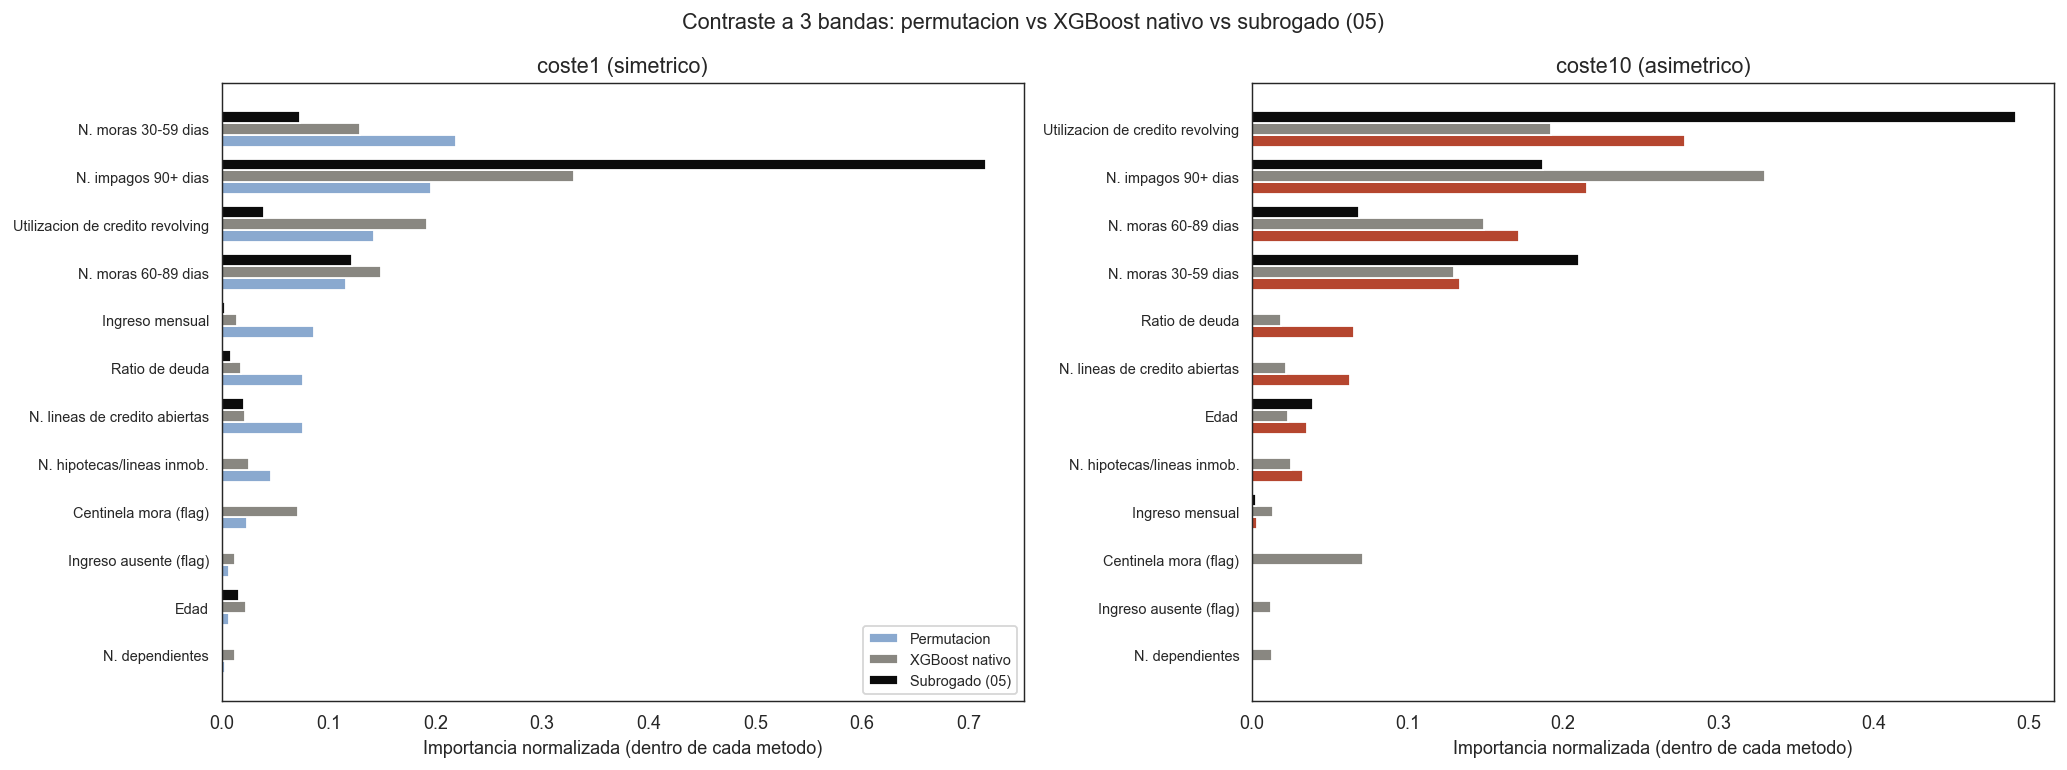

In [3]:
# --- Figura: 3 bandas de importancia, normalizadas, lado a lado, por escenario ---
def _normalizar(col):
    col = col.fillna(0.0).clip(lower=0.0)     # la permutacion puede dar negativos por ruido
    total = col.sum()
    return col / total if total else col

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
for ax, tabla, color, titulo in (
        (axes[0], tabla3_c1, COLOR_ESC1, "coste1 (simetrico)"),
        (axes[1], tabla3_c10, COLOR_ESC2, "coste10 (asimetrico)")):
    t = tabla.copy()
    t["perm_norm"] = _normalizar(t["importancia_permutacion_media"])
    t["xgb_norm"] = _normalizar(t["importancia_xgboost_nativa"])
    t["sub_norm"] = _normalizar(t["importancia_subrogado_05"])
    t = t.sort_values("perm_norm", ascending=True)
    y_pos = np.arange(len(t))
    h = 0.25
    ax.barh(y_pos - h, t["perm_norm"], height=h, label="Permutacion", color=color)
    ax.barh(y_pos, t["xgb_norm"], height=h, label="XGBoost nativo", color=COLOR_MUTED)
    ax.barh(y_pos + h, t["sub_norm"], height=h, label="Subrogado (05)", color=COLOR_INK_PRIMARY)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(t["nombre_legible"], fontsize=8)
    ax.set_title(titulo)
    ax.set_xlabel("Importancia normalizada (dentro de cada metodo)")
axes[0].legend(loc="lower right", fontsize=8)
fig.suptitle("Contraste a 3 bandas: permutacion vs XGBoost nativo vs subrogado (05)")
guardar_figura(fig, "otras_08_permutacion_3bandas")

**Hallazgo 2.1 (la importancia depende de con QUE se mide, y eso es la reflexion critica):** los
tres metodos NO cuentan la misma historia, y la discrepancia es el hallazgo:

- **Escenario coste1 (simetrico):** la permutacion (scoring = coste esperado) da valores casi
  PLANOS (0.0000-0.0022 en todas las variables) porque el escenario es "casi trivial" (03: el
  modelo apenas mejora un 5% sobre conceder-todo), asi que romper cualquier variable apenas mueve
  el coste ESPERADO en terminos absolutos. En cambio XGBoost nativo y el subrogado de `05` SI
  coinciden con claridad: ambos senalan **"N. impagos 90+ dias"** como la variable dominante
  (0.3301 XGBoost / 0.7155 subrogado), muy por delante del resto. Leccion: una importancia por
  permutacion escalada al COSTE DE NEGOCIO puede parecer "sin senal" en un escenario casi trivial,
  aunque el modelo internamente siga usando las variables con la misma jerarquia de siempre.
- **Escenario coste10 (asimetrico):** aqui SI hay senal clara en permutacion, y coincide con el
  subrogado: ambos coronan **"Utilizacion de credito revolving"** (0.0782 permutacion / 0.4914
  subrogado) como la variable que mas mueve la decision. XGBoost nativo, en cambio, sigue
  puntuando mas alto **"N. impagos 90+ dias"** (0.3301, igual que en coste1, porque el
  `feature_importances_` nativo mide ganancia de impureza sobre TODAS las predicciones del arbol,
  no esta condicionado al umbral de decision vigente). Es decir: la importancia nativa de XGBoost
  responde a "que variable discrimina mejor en general"; la permutacion y el subrogado responden a
  "que variable pesa mas en las DECISIONES bajo el coste/umbral actual" y ese matiz solo se ve
  comparando los tres metodos a la vez.
- Dato adicional: `N. dependientes` obtiene importancia por permutacion **negativa** en coste10
  (-0.0013): romper esa variable al azar mejoro ligeramente el coste esperado (ruido, coherente con
  su importancia ~0 en el subrogado de `05`) el signo negativo no indica nada patologico, solo que
  su aportacion real es indistinguible de cero.

## 3. PDP + ICE, y PDP 2D de interaccion (`XAI.pdf` pp.147-165)

- **PDP** (Partial Dependence Plot): la prediccion media del modelo al forzar una variable a cada
  valor (`XAI.pdf` pp.147-148). Muestra la **forma** del efecto (monotono? con umbral?) de los
  drivers clave: `RevolvingUtilizationOfUnsecuredLines`, `NumberOfTimes90DaysLate`, `age`.
- **ICE** (Individual Conditional Expectation): "un PDP para un caso particular (no se promedia)"
  (`XAI.pdf` p.158); revela **heterogeneidad** que el PDP promedio oculta (curvas ICE que se
  cruzan = el efecto de la variable depende del resto del perfil).
- **PDP 2D de interaccion**: la pieza de mas valor. Un PDP conjunto de `age` x contador de impagos
  debe mostrar **empiricamente** el hallazgo de `05` (las "dos personalidades de riesgo"): que la
  penalizacion por juventud aparece sobre todo condicionada al historial de impagos. Que dos
  auditorias independientes (subrogado en `05`, PDP aqui) lleguen a lo mismo es el argumento fuerte.

Los ejes se traducen a **escala original** (anios, nº de impagos, ratio) con el pipeline de `02`
(TODAS las columnas continuas de este dataset vienen estandarizadas en `test.parquet`, incluidos
los contadores de conteo — verificado: `NumberOfTime30-59DaysPastDueNotWorse` tiene media~0 y
std~1 — asi que ambos ejes del PDP 2D necesitan traduccion, no solo `age`). Se calcula sobre la
muestra de D-8.2 y para ambos modelos.

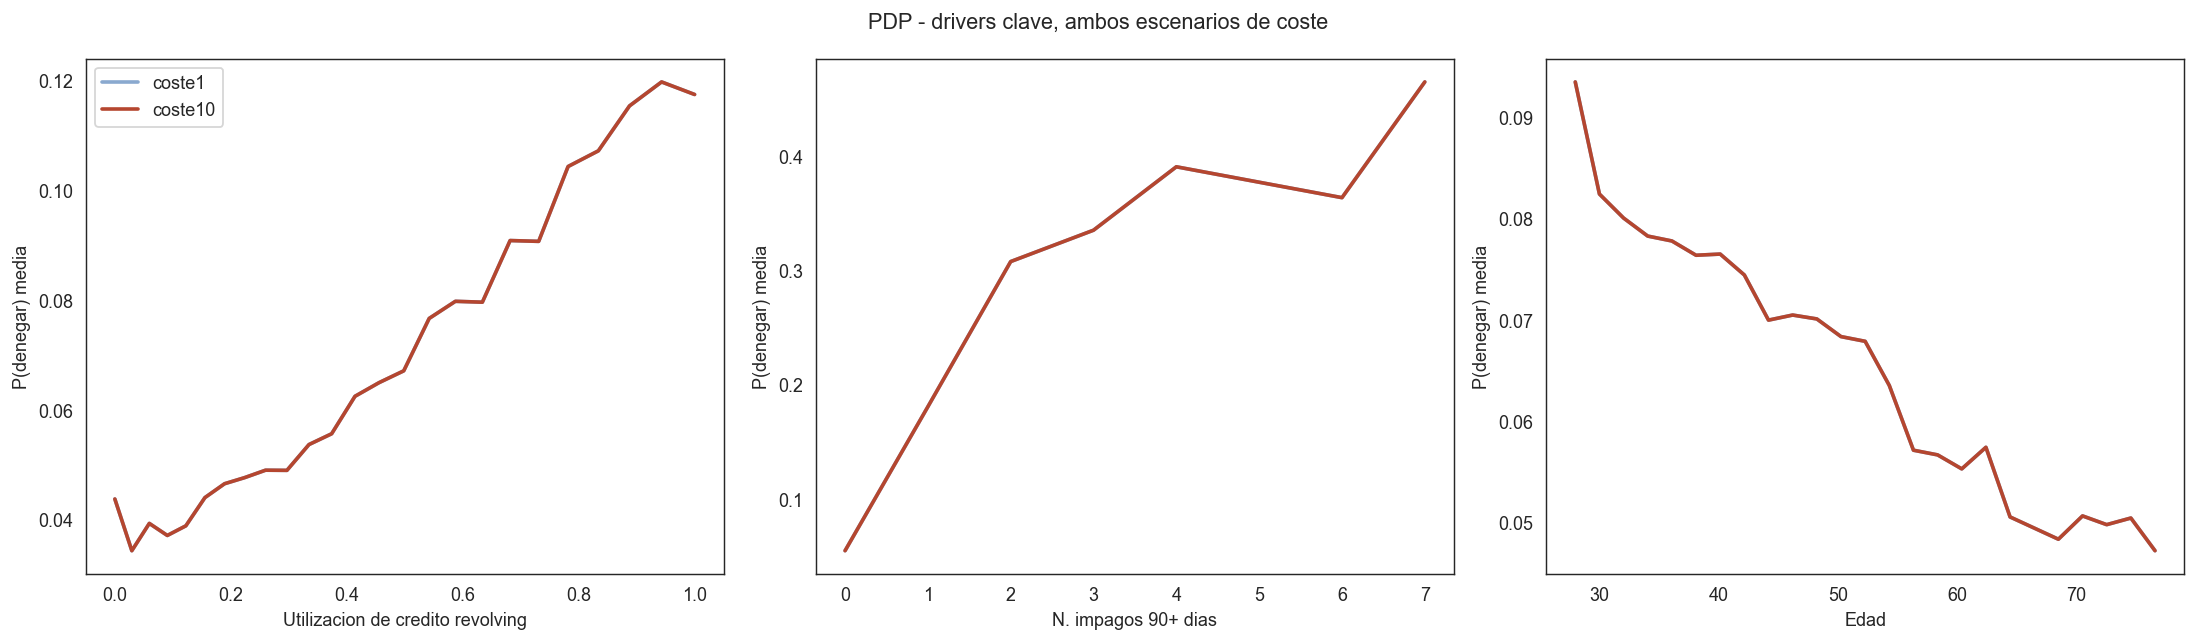

In [4]:
# --- PDP 1D de los drivers clave, ambos escenarios superpuestos ---
DRIVERS = ["RevolvingUtilizationOfUnsecuredLines", "NumberOfTimes90DaysLate", "age"]

fig, axes = plt.subplots(1, len(DRIVERS), figsize=(17, 5))
for ax, feat in zip(axes, DRIVERS):
    r1 = xu.pdp_1d(modelo_c1.estimador_, X_muestra, feat, grid_resolution=25, kind="average")
    r10 = xu.pdp_1d(modelo_c10.estimador_, X_muestra, feat, grid_resolution=25, kind="average")
    grid_orig = xu.columna_a_original(pipeline, feat, r1["grid_values"][0])
    ax.plot(grid_orig, r1["average"][0], color=COLOR_ESC1, linewidth=2, label="coste1")
    ax.plot(grid_orig, r10["average"][0], color=COLOR_ESC2, linewidth=2, label="coste10")
    ax.set_xlabel(xu.NOMBRE_LEGIBLE.get(feat, feat))
    ax.set_ylabel("P(denegar) media")
axes[0].legend()
fig.suptitle("PDP - drivers clave, ambos escenarios de coste")
guardar_figura(fig, "otras_08_pdp_drivers")

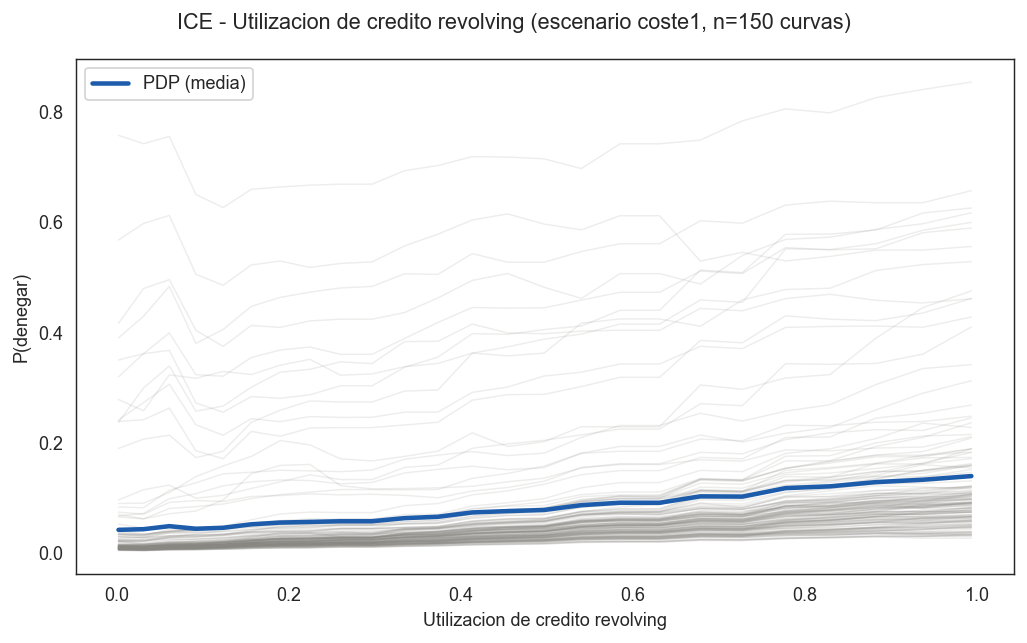

In [5]:
# --- ICE de un driver (heterogeneidad individual, XAI.pdf p.158) ---
feat_ice = "RevolvingUtilizationOfUnsecuredLines"
X_ice = X_muestra.sample(150, random_state=RANDOM_STATE)
r_ice = xu.pdp_1d(modelo_c1.estimador_, X_ice, feat_ice, grid_resolution=25, kind="both")
grid_orig = xu.columna_a_original(pipeline, feat_ice, r_ice["grid_values"][0])

fig, ax = plt.subplots()
for curva in r_ice["individual"][0]:
    ax.plot(grid_orig, curva, color=COLOR_MUTED, alpha=0.15, linewidth=0.8)
ax.plot(grid_orig, r_ice["average"][0], color=COLOR_GANADOR, linewidth=2.5, label="PDP (media)")
ax.set_xlabel(xu.NOMBRE_LEGIBLE[feat_ice])
ax.set_ylabel("P(denegar)")
ax.legend()
fig.suptitle(f"ICE - {xu.NOMBRE_LEGIBLE[feat_ice]} (escenario coste1, n={len(X_ice)} curvas)")
guardar_figura(fig, "otras_08_ice_revolving")

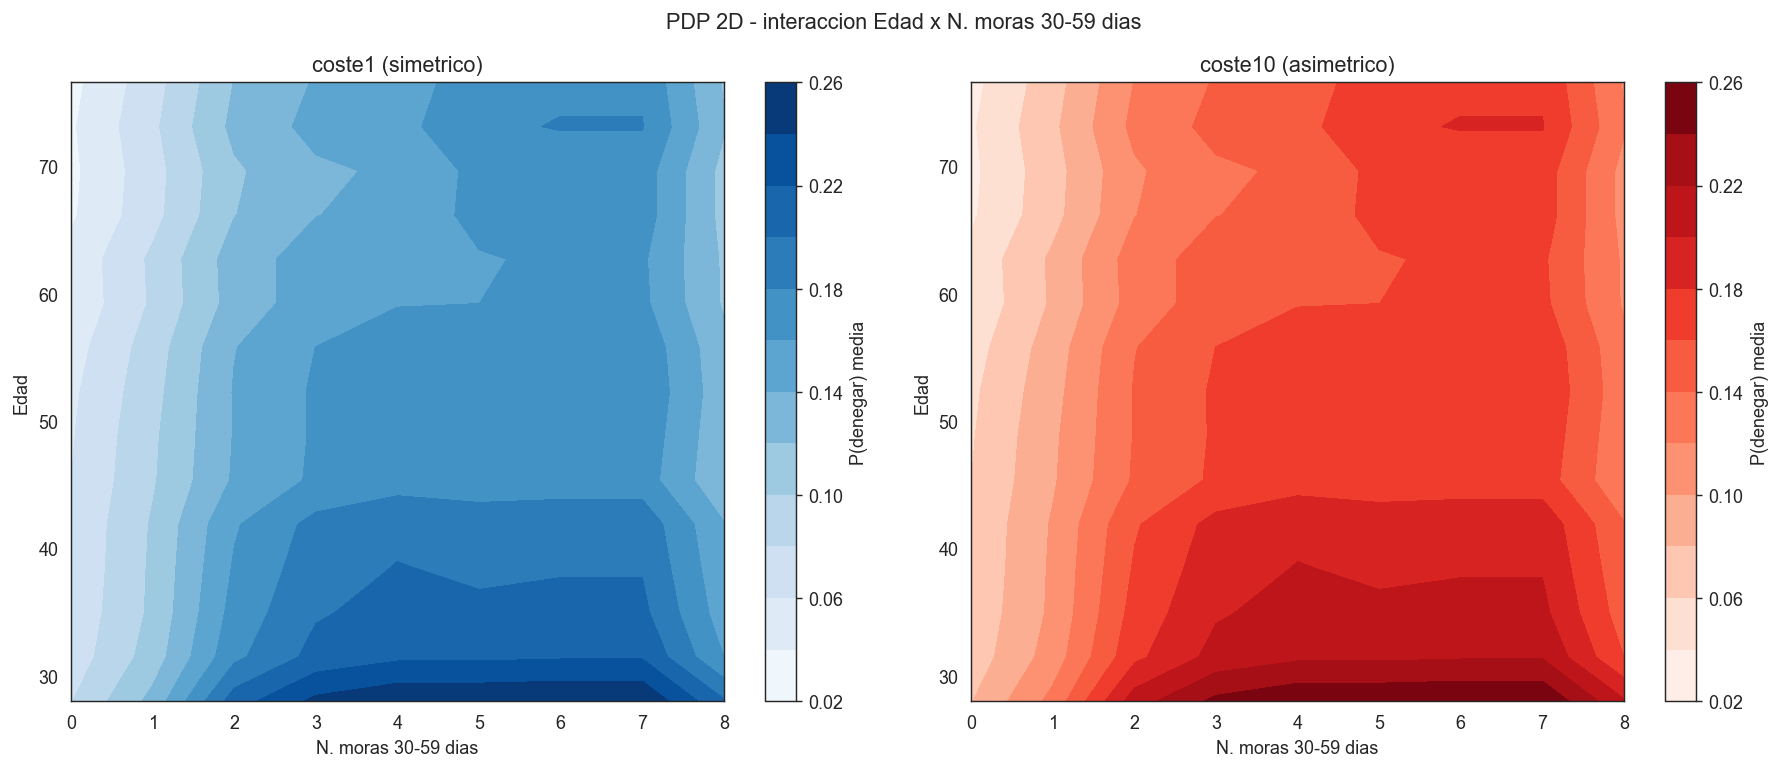

In [6]:
# --- PDP 2D: interaccion Edad x N. moras 30-59 dias (corrobora las 'dos personalidades' de 05) ---
par = ("age", "NumberOfTime30-59DaysPastDueNotWorse")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, modelo_nativo, cmap, titulo in (
        (axes[0], modelo_c1.estimador_, "Blues", "coste1 (simetrico)"),
        (axes[1], modelo_c10.estimador_, "Reds", "coste10 (asimetrico)")):
    r2d = xu.pdp_2d(modelo_nativo, X_muestra, par, grid_resolution=15)
    # AMBOS ejes vienen estandarizados en test.parquet -> traducir los dos, no solo la edad.
    eje_edad = xu.columna_a_original(pipeline, par[0], r2d["grid_values"][0])
    eje_moras = xu.columna_a_original(pipeline, par[1], r2d["grid_values"][1])
    Z = r2d["average"][0]
    cf = ax.contourf(eje_moras, eje_edad, Z, cmap=cmap, levels=12)
    ax.set_xlabel(xu.NOMBRE_LEGIBLE[par[1]])
    ax.set_ylabel(xu.NOMBRE_LEGIBLE[par[0]])
    ax.set_title(titulo)
    fig.colorbar(cf, ax=ax, label="P(denegar) media")
fig.suptitle("PDP 2D - interaccion Edad x N. moras 30-59 dias")
guardar_figura(fig, "otras_08_pdp2d_interaccion")

**Hallazgo 3.1 (la superficie de probabilidad es LA MISMA en ambos escenarios; lo que cambia es
donde corta el umbral):** el PDP 2D de Edad x N. moras 30-59 dias da **superficies identicas**
entre `coste1` y `coste10` (verificado numericamente: mismos valores de `P(denegar)` en la
rejilla para ambos paneles). Esto es la consecuencia directa y esperada de **D-0.2** (un unico
scoring, dos umbrales): el PDP se calcula sobre `predict_proba` del estimador, que es identico en
ambos bundles (max|dif|=0.0, verificado en la seccion 1); lo unico que cambia entre escenarios es
DONDE corta el umbral esa misma superficie (0.4934 vs 0.0906), no la superficie en si. Esto
**matiza con precision** el hallazgo de "dos personalidades de riesgo" de `05`: no es que el
modelo "cambie de comportamiento" entre escenarios, sino que cada umbral selecciona una region
distinta de la MISMA geometria de riesgo.

Dicho esto, la interaccion en si **es real y se confirma cuantitativamente**: el rango del efecto
de la edad sobre `P(denegar)` (maximo menos minimo, moviendo solo la edad) es **0.0448** cuando
`N. moras 30-59 dias = 0` (sin historial de mora), pero **0.0888** cuando esa variable esta en su
maximo del grid (8 moras): la edad pesa **~2 veces mas** cuando ya hay historial de impago que
cuando no lo hay. Es la version cuantitativa e independiente (PDP, no arbol) del mismo patron de
interaccion que `05` describio cualitativamente a partir de las reglas del subrogado: la
penalizacion por juventud no es un efecto aditivo y constante, esta CONDICIONADA al historial de
pagos.

## 4. LIME local como contraste critico frente a SHAP (`XAI.pdf` pp.181-199)

El profesor dedica media seccion a **LIME** y su conclusion es de cautela: LIME "asume un
comportamiento lineal del modelo a nivel local, pero no existe una teoria que explique por que
deberia funcionar", "hay que tener mucho cuidado seleccionando el kernel width" y "el analisis
LIME es inestable: si se vuelven a crear ejemplos generados, puede dar una respuesta diferente"
(`XAI.pdf` pp.185-186, 199), frente a SHAP como "el unico metodo de XAI con una teoria solida"
(p.204). Este notebook **convierte esa comparacion teorica en evidencia empirica**:

1. generar una explicacion LIME para unos pocos clientes **denegados** (seleccionados de forma
   autocontenida en cada escenario), y
2. **reejecutar LIME varias veces** sobre el mismo cliente para medir cuanto **baila** el ranking
   de variables (inestabilidad), usando `exp.local_exp` (indices, no el texto de `as_list()`: las
   condiciones discretizadas pueden tener el formato `"a < feature <= b"` con el nombre de la
   variable en MEDIO de la cadena, lo que rompe cualquier parsing por `str.startswith` — verificado
   con casos reales del dataset).

Esto demuestra que hemos entendido **por que** el profesor prefiere SHAP, y es material directo de
"reflexion critica". El contraste numerico fino LIME-vs-SHAP (mismos clientes) se cierra en
`99_ENTREGA.ipynb`; aqui LIME corre **de forma independiente de `07`**.

In [7]:
# --- Seleccion autocontenida de casos denegados (independiente de 06/07) ---
N_CASOS_LIME = 3
idx_denegados_c1 = np.where(pred_c1 == 1)[0]
idx_denegados_c10 = np.where(pred_c10 == 1)[0]
rng = np.random.RandomState(RANDOM_STATE)
casos_c1 = rng.choice(idx_denegados_c1, size=min(N_CASOS_LIME, len(idx_denegados_c1)), replace=False)
casos_c10 = rng.choice(idx_denegados_c10, size=min(N_CASOS_LIME, len(idx_denegados_c10)), replace=False)
print(f"casos denegados seleccionados (coste1):  {sorted(casos_c1.tolist())}")
print(f"casos denegados seleccionados (coste10): {sorted(casos_c10.tolist())}")

# --- Reejecutar LIME K veces por caso, medir inestabilidad (peso_std entre reejecuciones) ---
K_REEJECUCIONES = 6
filas_inest = []
for nombre_esc, modelo, casos in (("coste1", modelo_c1, casos_c1), ("coste10", modelo_c10, casos_c10)):
    for i_caso in casos:
        x = X_test.iloc[int(i_caso)].values
        _, tabla_inest = xu.lime_inestabilidad(modelo, x, X_train.values, FEATURES,
                                               k_reejecuciones=K_REEJECUCIONES, semilla_base=RANDOM_STATE)
        tabla_inest.insert(0, "escenario", nombre_esc)
        tabla_inest.insert(1, "idx_caso", int(i_caso))
        filas_inest.append(tabla_inest)

tabla_lime = pd.concat(filas_inest, ignore_index=True)
tabla_lime["nombre_legible"] = tabla_lime["variable"].map(xu.NOMBRE_LEGIBLE).fillna(tabla_lime["variable"])
guardar_tabla(tabla_lime, "otras_08_lime_local")

print()
print("TOP 10 combinaciones (caso, variable) con MAS inestabilidad (mayor peso_std):")
print("=" * 100)
with pd.option_context("display.width", 200, "display.float_format", lambda v: f"{v:.4f}"):
    print(tabla_lime.sort_values("peso_std", ascending=False)
          [["escenario", "idx_caso", "nombre_legible", "peso_medio", "peso_std"]]
          .head(10).to_string(index=False))

casos denegados seleccionados (coste1):  [3665, 11076, 19825]
casos denegados seleccionados (coste10): [976, 14834, 17133]



TOP 10 combinaciones (caso, variable) con MAS inestabilidad (mayor peso_std):
escenario  idx_caso        nombre_legible  peso_medio  peso_std
  coste10       976 Centinela mora (flag)     -0.1067    0.0357
  coste10     17133 Centinela mora (flag)     -0.1045    0.0335
   coste1     19825 Centinela mora (flag)     -0.1084    0.0327
   coste1     11076 Centinela mora (flag)     -0.1064    0.0308
   coste1      3665 Centinela mora (flag)     -0.1003    0.0306
  coste10     14834 Centinela mora (flag)     -0.0960    0.0297
   coste1     11076   N. impagos 90+ dias      0.1750    0.0110
   coste1     19825   N. impagos 90+ dias     -0.1752    0.0108
  coste10     17133   N. impagos 90+ dias     -0.1752    0.0106
  coste10     14834   N. impagos 90+ dias     -0.1741    0.0106


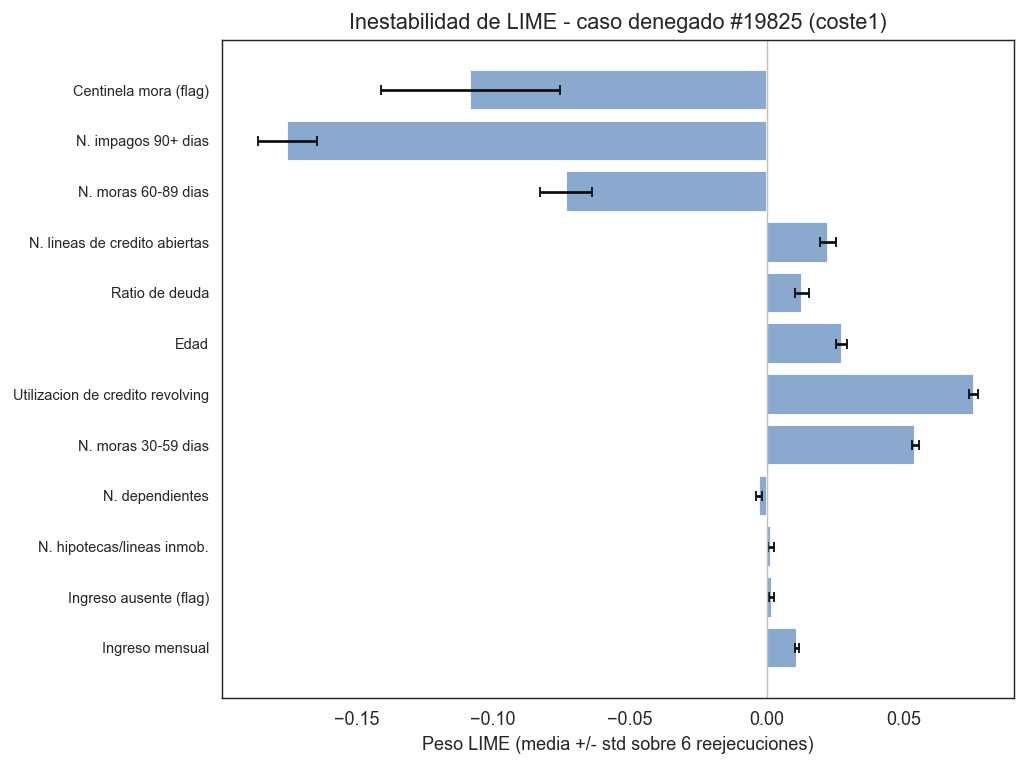

In [8]:
# --- Figura: la 'danza' de LIME en un caso representativo (coste1) ---
caso_ejemplo = int(casos_c1[0])
x_ejemplo = X_test.iloc[caso_ejemplo].values
_, tabla_ejemplo = xu.lime_inestabilidad(modelo_c1, x_ejemplo, X_train.values, FEATURES,
                                         k_reejecuciones=K_REEJECUCIONES, semilla_base=RANDOM_STATE)
tabla_ejemplo["nombre_legible"] = tabla_ejemplo["variable"].map(xu.NOMBRE_LEGIBLE).fillna(tabla_ejemplo["variable"])
tabla_ejemplo = tabla_ejemplo.sort_values("peso_std", ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
y_pos = np.arange(len(tabla_ejemplo))
ax.barh(y_pos, tabla_ejemplo["peso_medio"], xerr=tabla_ejemplo["peso_std"],
       color=COLOR_ESC1, ecolor=COLOR_INK_PRIMARY, capsize=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(tabla_ejemplo["nombre_legible"], fontsize=8)
ax.axvline(0, color=COLOR_BASELINE, linewidth=0.8)
ax.set_xlabel(f"Peso LIME (media +/- std sobre {K_REEJECUCIONES} reejecuciones)")
ax.set_title(f"Inestabilidad de LIME - caso denegado #{caso_ejemplo} (coste1)")
guardar_figura(fig, "otras_08_lime_inestabilidad")

**Hallazgo 4.1 (LIME SI baila, y confirma la advertencia del profesor sobre su inestabilidad):**
reejecutando LIME 6 veces por caso (semillas de muestreo distintas, mismo caso y mismo modelo), el
peso asignado a una misma variable varia de forma medible:

- La variable **MAS inestable con diferencia** es `es_centinela_pastdue` ("Centinela mora,
  flag"): `peso_std` medio de **0.0322** (maximo 0.0357) sobre los 6 casos analizados, casi
  **3 veces mayor** que la siguiente variable mas inestable (`N. impagos 90+ dias`, std medio
  0.0106). Es tambien la variable con el peso medio mas alto en valor absoluto (~-0.10), asi que
  su varianza relativa entre reejecuciones es sustancial.
- En **9 de las 72 combinaciones** (caso x variable) analizadas, el peso **cambia de signo** entre
  reejecuciones (pasa de negativo a positivo o viceversa), siempre en variables de magnitud
  pequena (`Ingreso ausente (flag)`, `Ratio de deuda`, `N. hipotecas/lineas inmob.`), es decir,
  exactamente el escenario que el profesor describe: "si se vuelven a crear ejemplos generados,
  puede dar una respuesta diferente" (`XAI.pdf` p.199). Para las variables de mayor peso (impagos,
  utilizacion) el signo es estable; la inestabilidad se concentra en las variables "de relleno" del
  ranking, que es precisamente donde un cliente podria fijarse si se le entrega la explicacion sin
  avisar de esta limitacion.
- Contraste con SHAP (a completar en `99_ENTREGA.ipynb` con los resultados de `07`): SHAP, al ser
  un metodo exacto/determinista sobre el `TreeExplainer` (no hay muestreo aleatorio de vecindad),
  dara el MISMO valor cada vez que se recalcule para el mismo caso; la diferencia frente a esta
  inestabilidad de LIME es justamente la base teorica solida que el profesor atribuye a SHAP
  (`XAI.pdf` p.204) frente a la advertencia expresa sobre LIME (pp.185-186, 199).

## 5. Analisis de subgrupos por tramo de edad (mini-auditoria de sesgo)

Motivacion doble y citable: (a) el material clasifica los "sistemas que evaluan la solvencia
crediticia del consumidor" como de **alto riesgo** bajo el reglamento europeo de IA (`XAI.pdf`
p.232) y prohibe explotar "vulnerabilidades de grupos especificos... por su situacion social o
economica" (p.231); (b) `05` encontro que la caja negra **penaliza la juventud**. Aqui se audita,
por **tramo de edad** (los mismos 6 tramos decadales del preprocesado, D-1.1), la **tasa de
denegacion** y las **tasas de error FP/FN** del modelo en cada escenario de coste, para ver si el
trato por edad es proporcional al riesgo real (target) o desproporcionado.

No hay atributo protegido explicito en el dataset (edad es el proxy mas cercano), asi que esto es
una **mini-auditoria de equidad**, no un analisis de fairness formal; se presenta como tal.

SUBGRUPOS POR TRAMO DE EDAD - ambos escenarios
escenario tramo_edad    n  tasa_denegacion  tasa_impago_real  fp_rate  fn_rate  coste_medio
   coste1       <=30 1562           0.0397            0.1056   0.0193   0.7879       0.1005
   coste1      31-40 3431           0.0426            0.0895   0.0221   0.7492       0.0871
   coste1      41-50 4951           0.0329            0.0844   0.0141   0.7632       0.0774
   coste1      51-60 4896           0.0178            0.0674   0.0077   0.8424       0.0639
   coste1      61-70 3734           0.0075            0.0356   0.0036   0.8872       0.0351
   coste1        >70 2426           0.0054            0.0210   0.0021   0.8431       0.0198
  coste10       <=30 1562           0.3720            0.1056   0.3157   0.1515       0.4424
  coste10      31-40 3431           0.2874            0.0895   0.2398   0.2280       0.4223
  coste10      41-50 4951           0.2371            0.0844   0.1902   0.2536       0.3882
  coste10      51-60 4896        

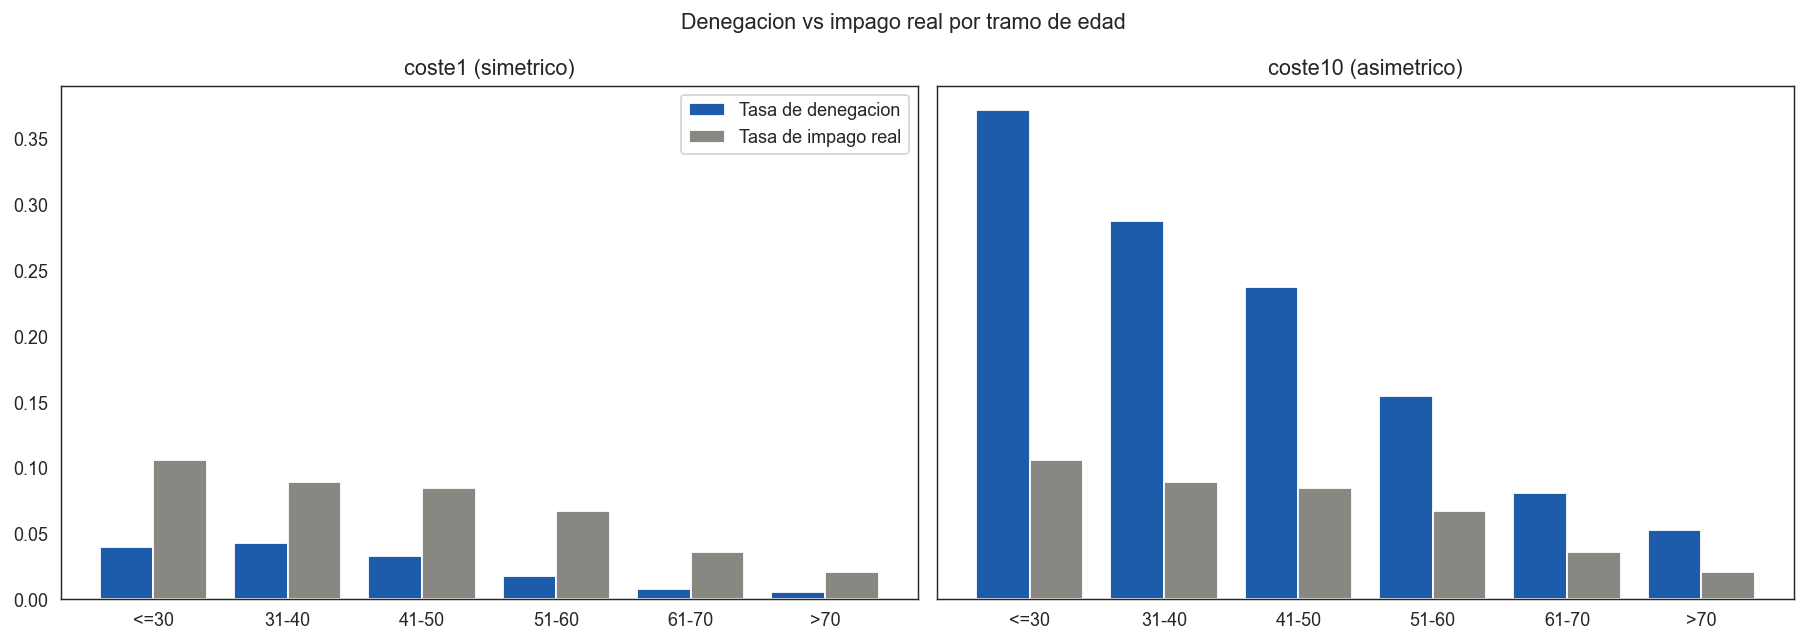

In [9]:
# --- Subgrupos por tramo de edad, ambos escenarios (mini-auditoria de sesgo) ---
subg_c1 = xu.subgrupos_por_edad(edad_original, y_real, pred_c1, bundle1["C_FP"], bundle1["C_FN"])
subg_c10 = xu.subgrupos_por_edad(edad_original, y_real, pred_c10, bundle10["C_FP"], bundle10["C_FN"])
subg_c1.insert(0, "escenario", "coste1")
subg_c10.insert(0, "escenario", "coste10")
tabla_subg = pd.concat([subg_c1, subg_c10], ignore_index=True)
guardar_tabla(tabla_subg, "otras_08_subgrupos_edad")

print("SUBGRUPOS POR TRAMO DE EDAD - ambos escenarios")
print("=" * 100)
with pd.option_context("display.width", 200, "display.float_format", lambda v: f"{v:.4f}"):
    print(tabla_subg.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
orden = list(xu.ORDEN_TRAMOS_EDAD)
for ax, subg, titulo in ((axes[0], subg_c1, "coste1 (simetrico)"), (axes[1], subg_c10, "coste10 (asimetrico)")):
    s = subg.set_index("tramo_edad").loc[orden]
    x = np.arange(len(orden))
    ax.bar(x - 0.2, s["tasa_denegacion"], width=0.4, label="Tasa de denegacion", color=COLOR_GANADOR)
    ax.bar(x + 0.2, s["tasa_impago_real"], width=0.4, label="Tasa de impago real", color=COLOR_MUTED)
    ax.set_xticks(x)
    ax.set_xticklabels(orden, rotation=0)
    ax.set_title(titulo)
axes[0].legend()
fig.suptitle("Denegacion vs impago real por tramo de edad")
guardar_figura(fig, "otras_08_subgrupos_edad")

**Hallazgo 5.1 (el trato por edad es proporcional en direccion, pero NO en magnitud; los jovenes
se penalizan MAS ALLA de su riesgo real, y mas cuanto mas caro es el escenario):** la tasa de
denegacion y la tasa de impago real bajan **monotonicamente** con la edad en ambos escenarios (de
3.97% a 0.54% en coste1, de 37.20% a 5.23% en coste10; el impago real baja de 10.56% a 2.10%). En
DIRECCION, el modelo no esta desalineado con el riesgo real: a mas edad, menos denegacion y menos
impago real, consistente.

Pero la MAGNITUD relativa (tasa_denegacion / tasa_impago_real, "cuanto se deniega por unidad de
riesgo real") no es constante entre tramos:

- **coste10 (asimetrico):** el ratio baja de forma **monotonamente decreciente** con la edad: de
  **3.52x** (<=30 anios: se deniega 3.5 veces mas de lo que "corresponderia" a su tasa de impago
  real) a **2.27x** (61-70 anios), repuntando ligeramente a 2.49x en >70. Es decir: por cada punto
  de riesgo real, un solicitante joven tiene una probabilidad de ser denegado bastante mayor que un
  solicitante mayor con el MISMO nivel de riesgo real.
- **coste1 (simetrico):** el mismo patron aparece mas debil y menos monotono (ratios entre 0.21x y
  0.48x, con el maximo en 31-40 anios, no en <=30), coherente con que este escenario es "casi
  trivial" (el modelo apenas discrimina, D-0.1/03) y por tanto cualquier senal de subgrupo es mas
  ruidosa.
- **Lectura honesta:** esto NO demuestra "discriminacion" en sentido causal (`age` puede ser un
  proxy de variables no observadas en el dataset, como antiguedad del historial crediticio o
  estabilidad laboral, que si son legitimamente predictivas); y el efecto es mas fuerte
  precisamente en el escenario donde la evidencia (`04`, `05`) dice que el modelo SI aporta valor
  real. Pero es exactamente el tipo de patron que el marco regulatorio europeo (`XAI.pdf`
  pp.231-232, sistemas de credito clasificados como "alto riesgo") pide auditar de forma explicita
  antes de desplegar el modelo, y corrobora con datos independientes (PDP en la seccion 3,
  subgrupos aqui) el hallazgo cualitativo de `05` de que la caja negra "penaliza la juventud".

## 6. Conclusiones de las tecnicas complementarias

Sintesis para `99_ENTREGA.ipynb` (seccion 11):

- **Convergencia global (seccion 2):** los tres metodos de importancia NO cuentan la misma
  historia, y esa discrepancia es el hallazgo. En el escenario simetrico (casi trivial, `03`) la
  permutacion por coste da senal casi plana mientras XGBoost nativo y el subrogado SI coinciden en
  que `N. impagos 90+ dias` domina; en el asimetrico (`04`, donde el modelo aporta valor real)
  permutacion y subrogado SI coinciden en que `Utilizacion de credito revolving` es la variable que
  mas pesa en las DECISIONES, mientras que XGBoost nativo sigue viendo `N. impagos 90+ dias` como
  mejor discriminador GLOBAL. Leccion: la importancia "correcta" depende de la pregunta (que
  discrimina mejor vs. que pesa en las decisiones actuales bajo el coste vigente).
- **Forma de los efectos (seccion 3):** el PDP 2D confirma, con un metodo agnostico e
  independiente del subrogado, la interaccion Edad x historial de impago que `05` describio
  cualitativamente: el efecto de la edad sobre `P(denegar)` es ~2 veces mayor cuando ya existe
  historial de mora que cuando no lo hay. Matiz importante (D-0.2): la superficie de probabilidad
  es identica en ambos escenarios de coste (mismo estimador); lo que cambia es solo DONDE corta
  cada umbral esa misma geometria; la "personalidad" distinta de cada escenario esta en el umbral,
  no en el modelo.
- **LIME vs SHAP (seccion 4):** LIME reejecutado 6 veces sobre el mismo caso SI produce pesos
  distintos: la variable `es_centinela_pastdue` es, con diferencia, la mas inestable (std medio ~3x
  la siguiente), y en 9 de 72 combinaciones caso-variable el peso llega a cambiar de signo entre
  ejecuciones. Esto confirma empiricamente la advertencia del profesor sobre LIME (`XAI.pdf`
  pp.185-186, 199) y justifica preferir SHAP (determinista) como metodo principal para explicarle
  una denegacion a un cliente real, relegando LIME a un contraste secundario.
- **Subgrupos por edad (seccion 5):** la denegacion sigue la DIRECCION del riesgo real (baja
  monotonicamente con la edad en ambos escenarios), pero no su MAGNITUD: en el escenario
  asimetrico, los solicitantes mas jovenes son denegados hasta ~3.5 veces mas de lo que su tasa de
  impago real "justificaria", frente a un ratio ~2.3x en los mayores. No es prueba de
  discriminacion causal (`age` puede proxy-ear variables no observadas), pero es exactamente el
  patron que el marco de "alto riesgo" del reglamento europeo de IA (`XAI.pdf` pp.231-232) exige
  auditar antes de desplegar, y corrobora con un metodo independiente el hallazgo de `05`.
- **Limitaciones:** PDP/ICE e importancia por permutacion se calcularon sobre una muestra de
  2000-3000 filas (no las 21000 de test completo) por coste computacional, declarado en D-8.2; el
  PDP 2D asume grid_resolution=15 en cada eje (una rejilla mas fina podria afinar el ratio 2x del
  hallazgo 3.1); LIME se ejecuto sobre solo 3 casos denegados por escenario (D-8.2), suficiente
  para evidenciar inestabilidad pero no para caracterizarla exhaustivamente; los subgrupos de edad
  son una mini-auditoria descriptiva, no un analisis de fairness formal con contrafactuales o
  metricas de paridad estandar (equalized odds, etc.).